In [ ]:
pip install numpy scipy matplotlib plotly pandas

In [ ]:
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# Scipy.stats
from scipy.stats import norm

# Random Generator
rng = np.random.default_rng(123)

import time
import datetime as dt

In [ ]:
def MC_options_is(S, K, T, r, sigma, N, option_type='call', is_shift=True):
    """
    Monte Carlo simulation for European options with importance sampling
    """
    if is_shift:
      mu_shift = (np.log(K) - np.log(S) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    else:
      mu_shift = 0

    X = rng.normal(mu_shift, 1, N)

    # Calculate stock prices at expiration
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)

    # Calculate discounted payoffs
    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(ST - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - ST, 0)

    weight = np.exp(-mu_shift * X + 0.5 * mu_shift**2)
    payoffs *= weight

    # Calculate price and variance
    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance

In [ ]:
def MC_asian_options_is(S, K, T, r, sigma, N, n_steps=252, option_type='call', avg_type='arithmetic'):
    """
    Asian options with importance sampling
    """
    dt = T / n_steps

    # Importance sampling: shift the distribution toward the average being near K
    # We approximate by shifting the final distribution
    mu_shift = (np.log(K) - np.log(S) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    Z = rng.normal(mu_shift / n_steps, 1, (N, n_steps))  # Distribute shift across steps

    # Simulate price paths
    prices = np.zeros((N, n_steps + 1))
    prices[:, 0] = S

    for t in range(1, n_steps + 1):
        prices[:, t] = prices[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

    # Calculate average price
    if avg_type == 'arithmetic':
        avg_price = np.mean(prices[:, 1:], axis=1)
    else:  # geometric
        avg_price = np.exp(np.mean(np.log(prices[:, 1:]), axis=1))

    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(avg_price - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - avg_price, 0)

    # Importance sampling weight (cumulative across all steps)
    total_shift = mu_shift / n_steps
    weights = np.exp(-total_shift * np.sum(Z, axis=1) + 0.5 * total_shift**2 * n_steps)
    payoffs *= weights

    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance, prices

In [ ]:
#Testcase1: Hardcode
S = 60
K_call = 65
K_put = 55
T = 1.0
r = 0.03
sigma_call = 0.3
sigma_put = 0.3


N = 10000
European Call: 5.847804 ± 0.156130 (Error: 1.362191%)
European Put: 3.956936 ± 0.097798 (Error: 1.260996%)
Asian Call: 2.557209 ± 0.105299 (Error: 2.100888%)
Asian Put: 1.684707 ± 0.064086 (Error: 1.940802%)
Computation time (European): 0.001096 seconds
Computation time (Asian): 0.370358 seconds

N = 100000
European Call: 5.937457 ± 0.049947 (Error: 0.429195%)
European Put: 3.926493 ± 0.030669 (Error: 0.398511%)
Asian Call: 2.586055 ± 0.033696 (Error: 0.664795%)
Asian Put: 1.642848 ± 0.020074 (Error: 0.623432%)
Computation time (European): 0.006013 seconds
Computation time (Asian): 2.889969 seconds

N = 1000000
European Call: 5.897845 ± 0.015723 (Error: 0.136019%)
European Put: 3.936749 ± 0.009704 (Error: 0.125760%)
Asian Call: 2.579169 ± 0.010648 (Error: 0.210628%)
Asian Put: 1.656137 ± 0.006375 (Error: 0.196384%)
Computation time (European): 0.069370 seconds
Computation time (Asian): 33.808480 seconds


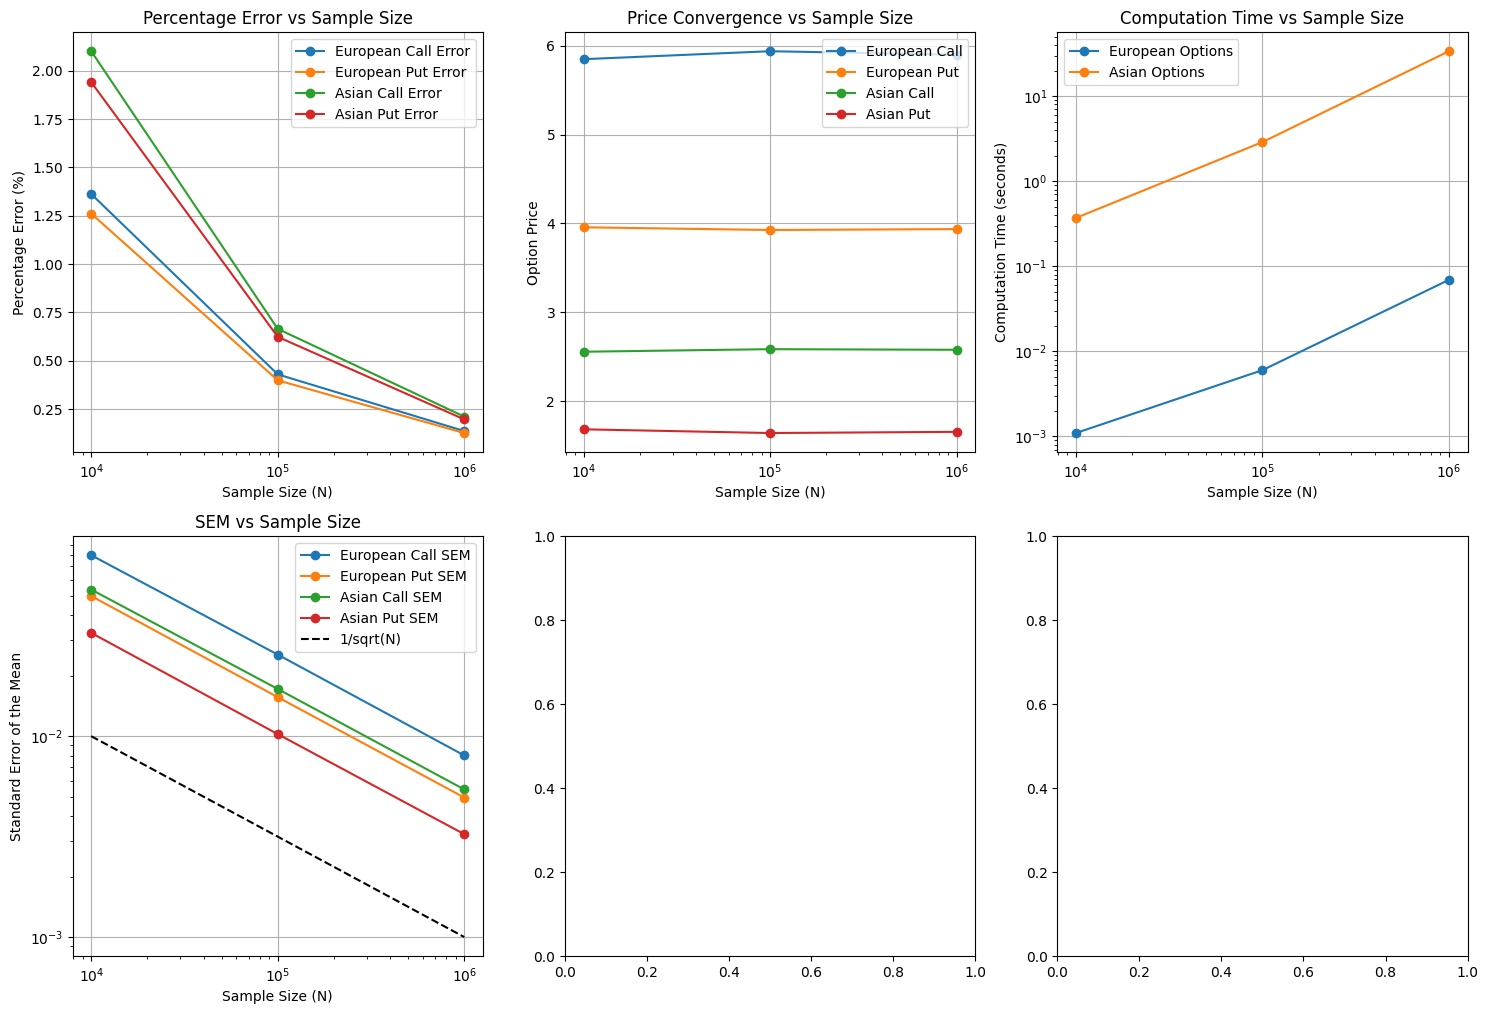

In [ ]:
# Compare Monte Carlo estimates for different sample sizes
sample_sizes = [10**4, 10**5, 10**6]

call_results = []
put_results = []
computation_times_european = []

asian_call_results = []
asian_put_results = []
computation_times_asian = []

for N in sample_sizes:
    print(f"\nN = {N}")

    # European Call option
    start_time = time.time()
    MC_call_price, var_call = MC_options_is(S, K_call, T, r, sigma_call, N, 'call', True)
    SEM_call = np.sqrt(var_call / N)
    perc_error_call = SEM_call / MC_call_price * 100 if MC_call_price > 0 else 0
    end_time = time.time()
    comp_time_european = end_time - start_time

    call_results.append({
        'N': N,
        'price': MC_call_price,
        'SEM': SEM_call,
        'perc_error': perc_error_call
    })

    # European Put option
    start_time = time.time()
    MC_put_price, var_put = MC_options_is(S, K_put, T, r, sigma_put, N, 'put', True)
    SEM_put = np.sqrt(var_put / N)
    perc_error_put = SEM_put / MC_put_price * 100 if MC_put_price > 0 else 0
    comp_time_european += (time.time() - start_time)

    put_results.append({
        'N': N,
        'price': MC_put_price,
        'SEM': SEM_put,
        'perc_error': perc_error_put
    })

    computation_times_european.append(comp_time_european)

    # Asian Call option
    start_time = time.time()
    asian_call_price, var_asian_call, _ = MC_asian_options_is(S, K_call, T, r, sigma_call, N, n_steps=252, option_type='call', avg_type='arithmetic')
    SEM_asian_call = np.sqrt(var_asian_call / N)
    perc_error_asian_call = SEM_asian_call / asian_call_price * 100 if asian_call_price > 0 else 0
    end_time = time.time()
    comp_time_asian = end_time - start_time

    asian_call_results.append({
        'N': N,
        'price': asian_call_price,
        'SEM': SEM_asian_call,
        'perc_error': perc_error_asian_call
    })

    # Asian Put option
    start_time = time.time()
    asian_put_price, var_asian_put, _ = MC_asian_options_is(S, K_put, T, r, sigma_put, N, n_steps=252, option_type='put', avg_type='arithmetic')
    SEM_asian_put = np.sqrt(var_asian_put / N)
    perc_error_asian_put = SEM_asian_put / asian_put_price * 100 if asian_put_price > 0 else 0
    comp_time_asian += (time.time() - start_time)

    asian_put_results.append({
        'N': N,
        'price': asian_put_price,
        'SEM': SEM_asian_put,
        'perc_error': perc_error_asian_put
    })

    computation_times_asian.append(comp_time_asian)

    print(f"European Call: {MC_call_price:.6f} ± {1.96*SEM_call:.6f} (Error: {perc_error_call:.6f}%)")
    print(f"European Put: {MC_put_price:.6f} ± {1.96*SEM_put:.6f} (Error: {perc_error_put:.6f}%)")
    print(f"Asian Call: {asian_call_price:.6f} ± {1.96*SEM_asian_call:.6f} (Error: {perc_error_asian_call:.6f}%)")
    print(f"Asian Put: {asian_put_price:.6f} ± {1.96*SEM_asian_put:.6f} (Error: {perc_error_asian_put:.6f}%)")
    print(f"Computation time (European): {comp_time_european:.6f} seconds")
    print(f"Computation time (Asian): {comp_time_asian:.6f} seconds")

# Plotting results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Percentage error plot
axes[0,0].semilogx(sample_sizes, [res['perc_error'] for res in call_results], 'o-', label='European Call Error')
axes[0,0].semilogx(sample_sizes, [res['perc_error'] for res in put_results], 'o-', label='European Put Error')
axes[0,0].semilogx(sample_sizes, [res['perc_error'] for res in asian_call_results], 'o-', label='Asian Call Error')
axes[0,0].semilogx(sample_sizes, [res['perc_error'] for res in asian_put_results], 'o-', label='Asian Put Error')
axes[0,0].set_xlabel('Sample Size (N)')
axes[0,0].set_ylabel('Percentage Error (%)')
axes[0,0].set_title('Percentage Error vs Sample Size')
axes[0,0].legend()
axes[0,0].grid(True)

# SEM plot
axes[1,0].loglog(sample_sizes, [res['SEM'] for res in call_results], 'o-', label='European Call SEM')
axes[1,0].loglog(sample_sizes, [res['SEM'] for res in put_results], 'o-', label='European Put SEM')
axes[1,0].loglog(sample_sizes, [res['SEM'] for res in asian_call_results], 'o-', label='Asian Call SEM')
axes[1,0].loglog(sample_sizes, [res['SEM'] for res in asian_put_results], 'o-', label='Asian Put SEM')
axes[1,0].loglog(sample_sizes, [1/np.sqrt(N) for N in sample_sizes], 'k--', label='1/sqrt(N)')
axes[1,0].set_xlabel('Sample Size (N)')
axes[1,0].set_ylabel('Standard Error of the Mean')
axes[1,0].set_title('SEM vs Sample Size')
axes[1,0].legend()
axes[1,0].grid(True)

<Figure size 640x480 with 0 Axes>


Detailed Results for European Options:
Sample Size	Call Price	Put Price	Call Error (%)	Put Error (%)	Time (s)
10000		5.847804	3.956936	1.362191		1.260996		0.001096
100000		5.937457	3.926493	0.429195		0.398511		0.006013
1000000		5.897845	3.936749	0.136019		0.125760		0.069370

Detailed Results for Asian Options:
Sample Size	Call Price	Put Price	Call Error (%)	Put Error (%)	Time (s)
10000		2.557209	1.684707	2.100888		1.940802		0.370358
100000		2.586055	1.642848	0.664795		0.623432		2.889969
1000000		2.579169	1.656137	0.210628		0.196384		33.808480


Comparing options for different strike prices (N=1000000)

Strike Price: 20.00
European Call: 30.842808 ± 5.175072
European Put: 0.000203 ± 0.000001
Asian Call: 39.679546 ± 0.038575
Asian Put: 0.000000 ± 0.000000

Strike Price: 25.00
European Call: 31.241487 ± 2.184045
European Put: 0.004067 ± 0.000010
Asian Call: 34.842913 ± 0.032901
Asian Put: 0.000000 ± 0.000000

Strike Price: 30.00
European Call: 30.909700 ± 1.445763
European Put: 0.032743 

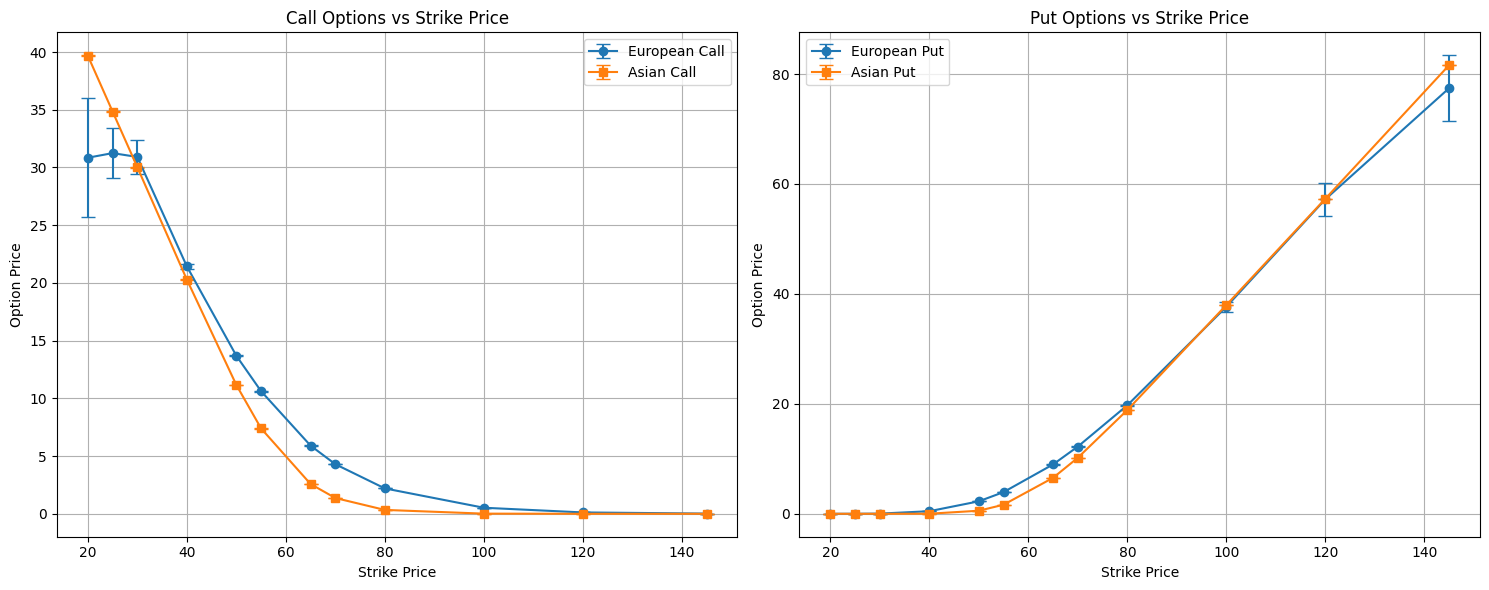


Strike Price Analysis Summary:
Strike	European Call	European Put	Asian Call	Asian Put
20.00	30.8428		0.0002		39.6795		0.0000
25.00	31.2415		0.0041		34.8429		0.0000
30.00	30.9097		0.0327		30.0185		0.0000
40.00	21.4353		0.4702		20.2918		0.0151
50.00	13.6902		2.2708		11.1616		0.5578
55.00	10.6189		3.9470		7.3949		1.6497
65.00	5.9034		8.9840		2.5780		6.5450
70.00	4.2953		12.2284		1.3669		10.1959
80.00	2.1990		19.7402		0.3364		18.8727
100.00	0.5245		37.6651		0.0134		37.9732
120.00	0.1178		57.2104		0.0005		57.3093
145.00	0.0180		77.4186		0.0000		81.6077


In [ ]:
# Price comparison at largest sample size
N_max = 10**6
option_types = ['European Call', 'European Put', 'Asian Call', 'Asian Put']
prices = [
    call_results[-1]['price'],
    put_results[-1]['price'],
    asian_call_results[-1]['price'],
    asian_put_results[-1]['price']
]
errors = [
    1.96 * call_results[-1]['SEM'],
    1.96 * put_results[-1]['SEM'],
    1.96 * asian_call_results[-1]['SEM'],
    1.96 * asian_put_results[-1]['SEM']
]

x_pos = np.arange(len(option_types))
axes[1,1].bar(x_pos, prices, yerr=errors, capsize=5, alpha=0.7)
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(option_types, rotation=45)
axes[1,1].set_ylabel('Option Price')
axes[1,1].set_title(f'Option Prices Comparison (N={N_max})')
axes[1,1].grid(True, alpha=0.3)

# Remove empty subplot
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Display detailed results
print("\nDetailed Results for European Options:")
print("Sample Size\tCall Price\tPut Price\tCall Error (%)\tPut Error (%)\tTime (s)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{call_results[i]['price']:.6f}\t{put_results[i]['price']:.6f}\t"
          f"{call_results[i]['perc_error']:.6f}\t\t{put_results[i]['perc_error']:.6f}\t\t{computation_times_european[i]:.6f}")

print("\nDetailed Results for Asian Options:")
print("Sample Size\tCall Price\tPut Price\tCall Error (%)\tPut Error (%)\tTime (s)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{asian_call_results[i]['price']:.6f}\t{asian_put_results[i]['price']:.6f}\t"
          f"{asian_call_results[i]['perc_error']:.6f}\t\t{asian_put_results[i]['perc_error']:.6f}\t\t{computation_times_asian[i]:.6f}")

# Compare Monte Carlo estimates for different strike prices (including Asian options)
strike_prices = [20,25,30,40,50,55,65,70,80,100,120,145]
N_fixed = 10**6  # Fixed sample size for strike price comparison

print(f"\n\nComparing options for different strike prices (N={N_fixed})")

european_call_prices = []
european_put_prices = []
asian_call_prices = []
asian_put_prices = []

european_call_errors = []
european_put_errors = []
asian_call_errors = []
asian_put_errors = []

for K in strike_prices:
    print(f"\nStrike Price: {K:.2f}")

    # European Call option
    MC_call_price, var_call = MC_options_is(S, K, T, r, sigma_call, N_fixed, 'call', True)
    SEM_call = np.sqrt(var_call / N_fixed)
    european_call_prices.append(MC_call_price)
    european_call_errors.append(1.96 * SEM_call)

    # European Put option
    MC_put_price, var_put = MC_options_is(S, K, T, r, sigma_put, N_fixed, 'put', True)
    SEM_put = np.sqrt(var_put / N_fixed)
    european_put_prices.append(MC_put_price)
    european_put_errors.append(1.96 * SEM_put)

    # Asian Call option
    asian_call_price, var_asian_call, _ = MC_asian_options_is(S, K, T, r, sigma_call, N_fixed, n_steps=252, option_type='call', avg_type='arithmetic')
    SEM_asian_call = np.sqrt(var_asian_call / N_fixed)
    asian_call_prices.append(asian_call_price)
    asian_call_errors.append(1.96 * SEM_asian_call)

    # Asian Put option
    asian_put_price, var_asian_put, _ = MC_asian_options_is(S, K, T, r, sigma_put, N_fixed, n_steps=252, option_type='put', avg_type='arithmetic')
    SEM_asian_put = np.sqrt(var_asian_put / N_fixed)
    asian_put_prices.append(asian_put_price)
    asian_put_errors.append(1.96 * SEM_asian_put)

    print(f"European Call: {MC_call_price:.6f} ± {1.96*SEM_call:.6f}")
    print(f"European Put: {MC_put_price:.6f} ± {1.96*SEM_put:.6f}")
    print(f"Asian Call: {asian_call_price:.6f} ± {1.96*SEM_asian_call:.6f}")
    print(f"Asian Put: {asian_put_price:.6f} ± {1.96*SEM_asian_put:.6f}")

# Plotting strike price comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Call options comparison
axes[0].errorbar(strike_prices, european_call_prices, yerr=european_call_errors,
                fmt='o-', label='European Call', capsize=5)
axes[0].errorbar(strike_prices, asian_call_prices, yerr=asian_call_errors,
                fmt='s-', label='Asian Call', capsize=5)
axes[0].set_xlabel('Strike Price')
axes[0].set_ylabel('Option Price')
axes[0].set_title('Call Options vs Strike Price')
axes[0].legend()
axes[0].grid(True)

# Put options comparison
axes[1].errorbar(strike_prices, european_put_prices, yerr=european_put_errors,
                fmt='o-', label='European Put', capsize=5)
axes[1].errorbar(strike_prices, asian_put_prices, yerr=asian_put_errors,
                fmt='s-', label='Asian Put', capsize=5)
axes[1].set_xlabel('Strike Price')
axes[1].set_ylabel('Option Price')
axes[1].set_title('Put Options vs Strike Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Display strike price results
print("\nStrike Price Analysis Summary:")
print("Strike\tEuropean Call\tEuropean Put\tAsian Call\tAsian Put")
for i, K in enumerate(strike_prices):
    print(f"{K:.2f}\t{european_call_prices[i]:.4f}\t\t{european_put_prices[i]:.4f}\t\t"
          f"{asian_call_prices[i]:.4f}\t\t{asian_put_prices[i]:.4f}")